<a href="https://colab.research.google.com/github/carrisian/del-big-data-al-modelo-predictivo/blob/main/Analisis%20Multivariente%20mediante%20Redes%20LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📈 Generando 16 gráficas para: ['PM10', 'PM2.5', 'NO2', 'Ozono']


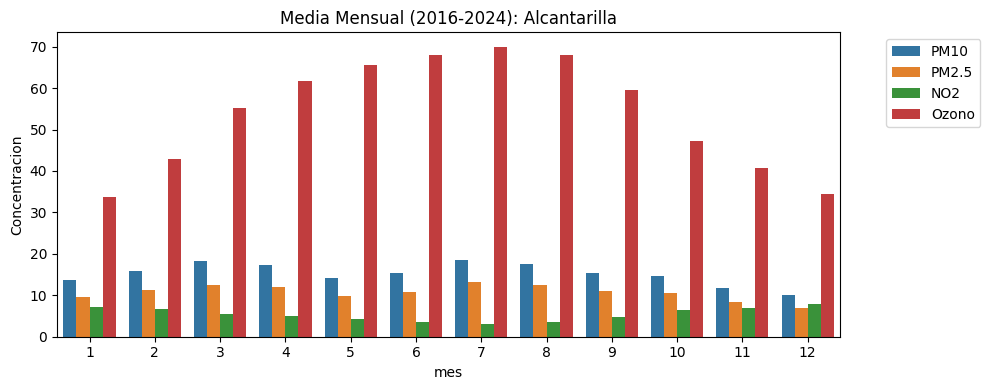

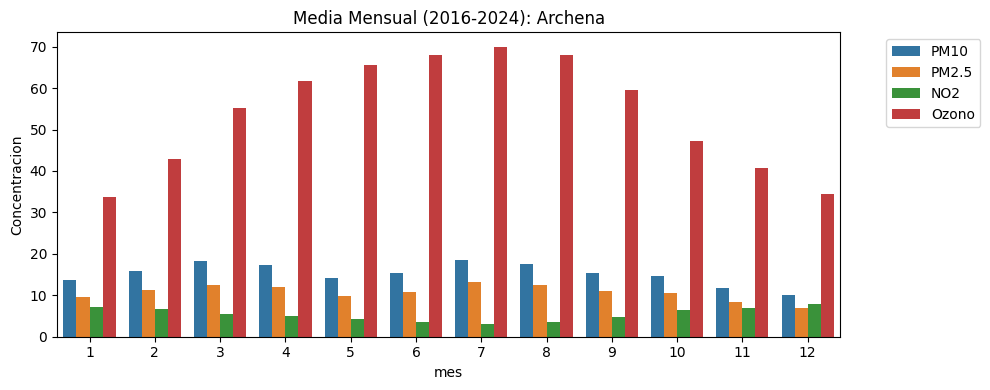

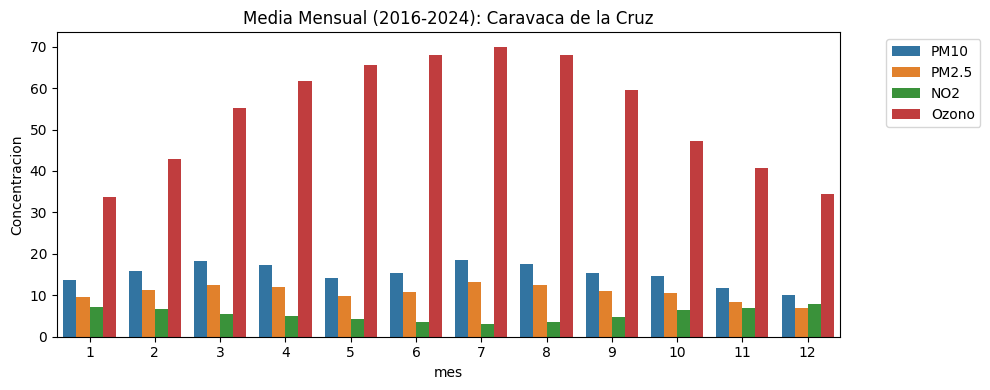

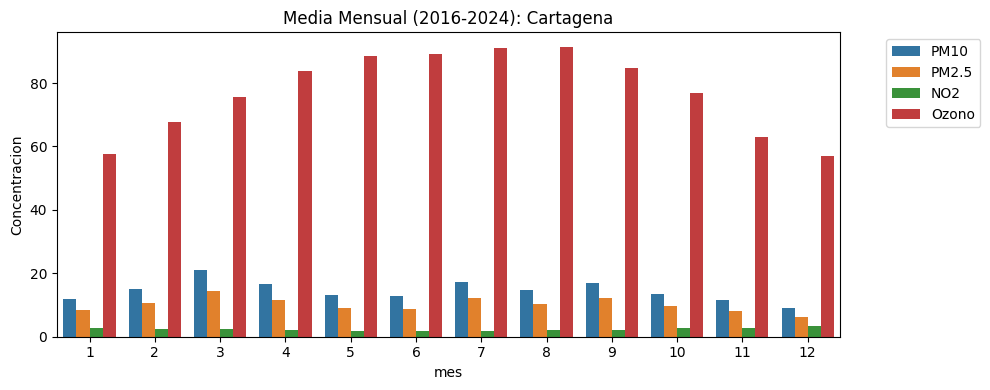

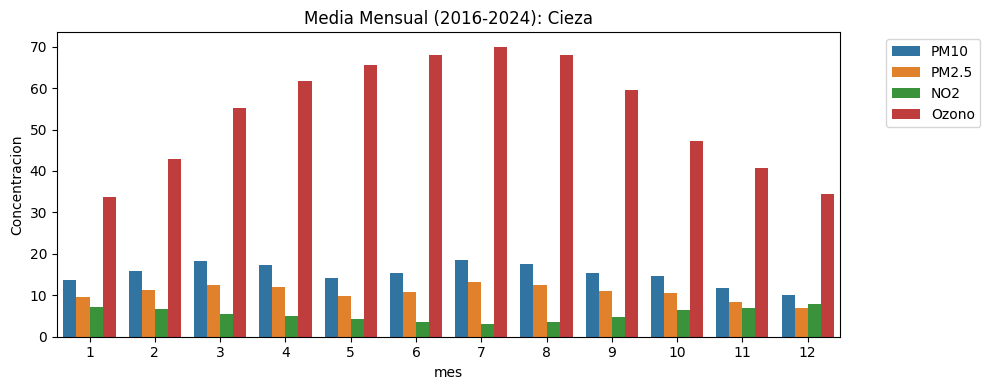

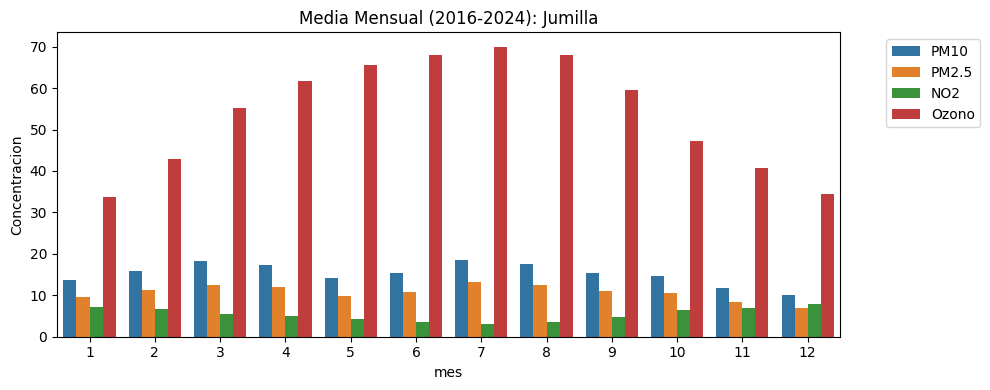

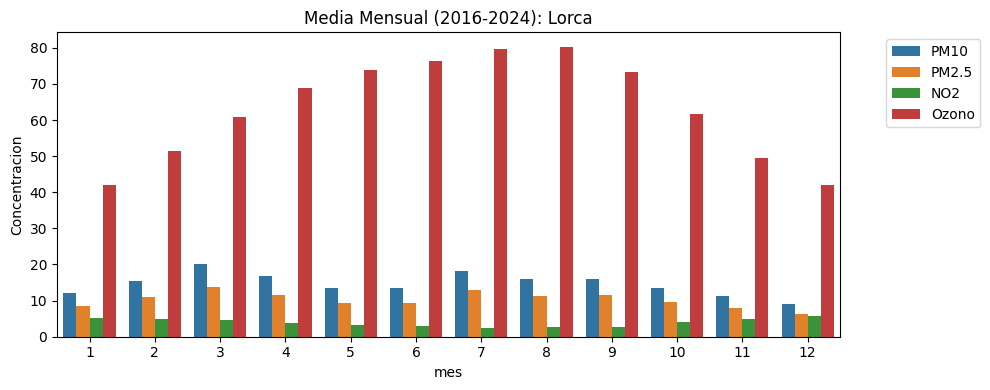

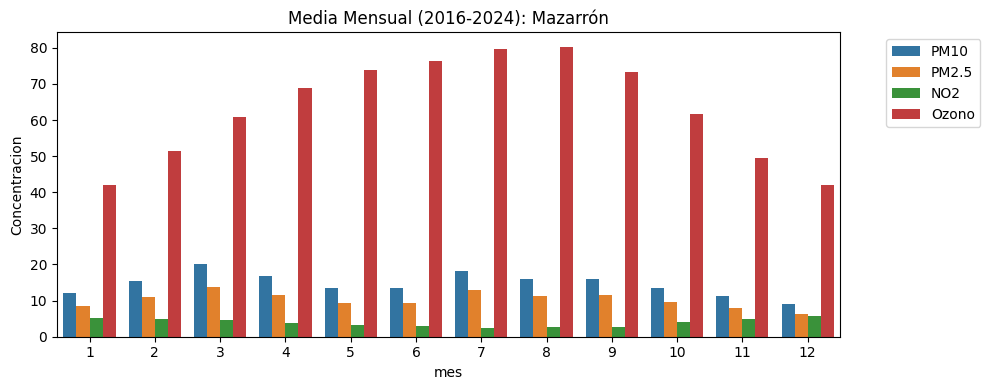

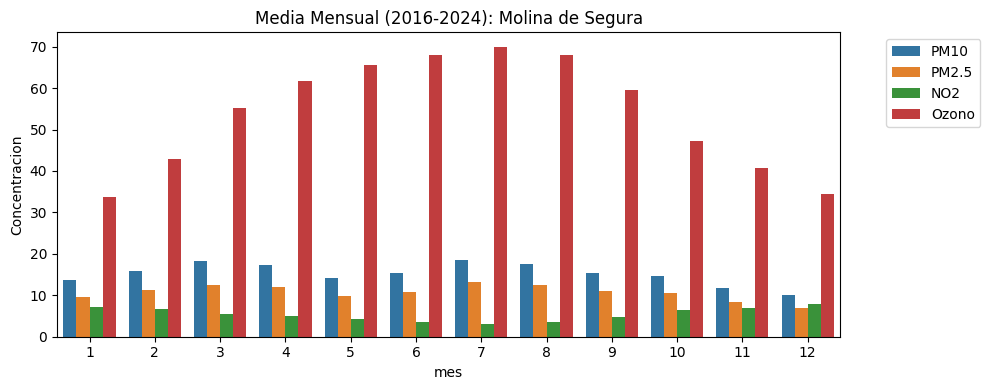

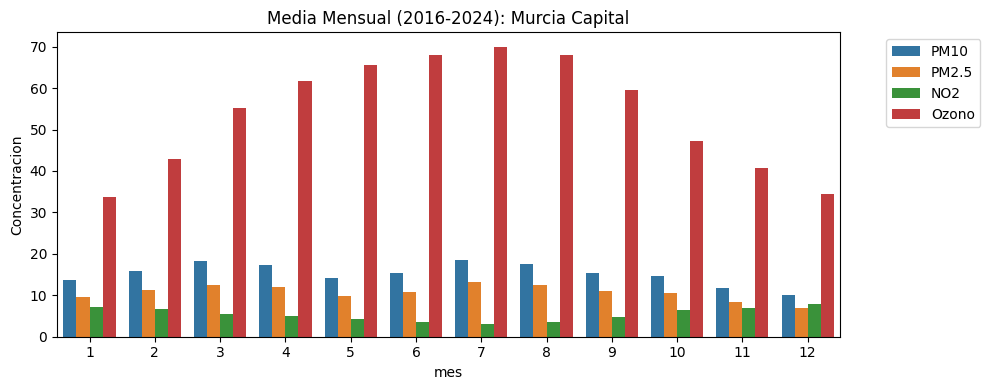

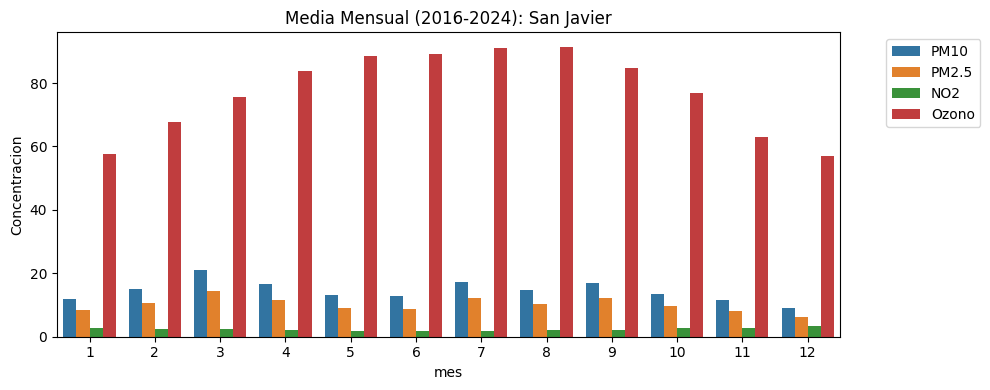

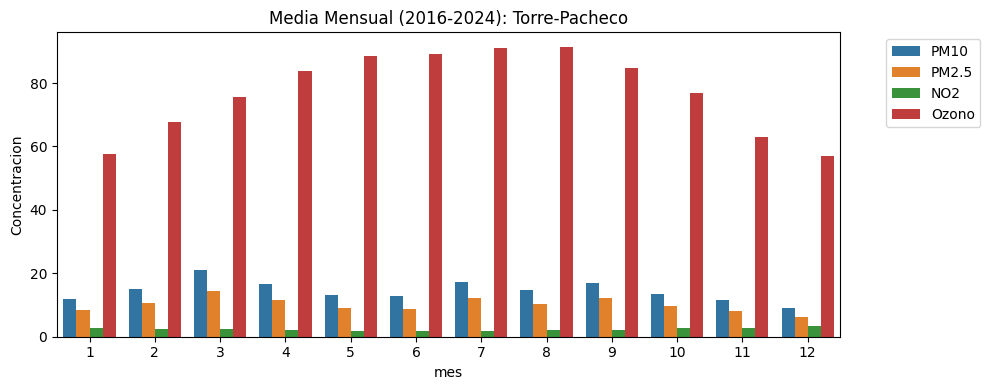

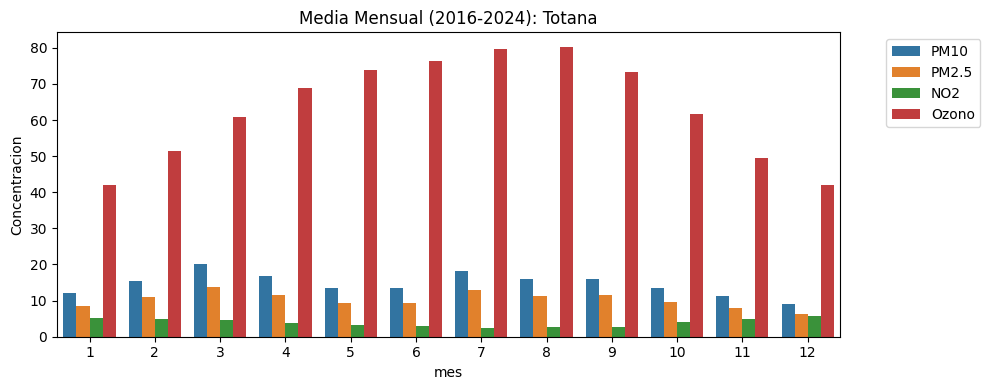

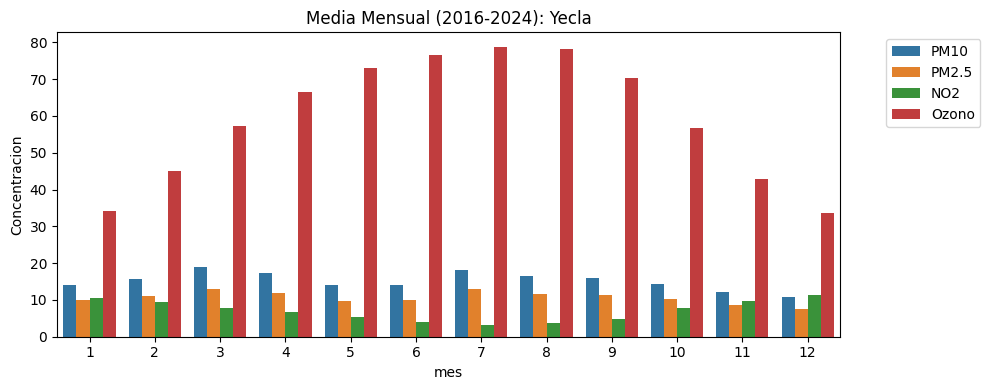

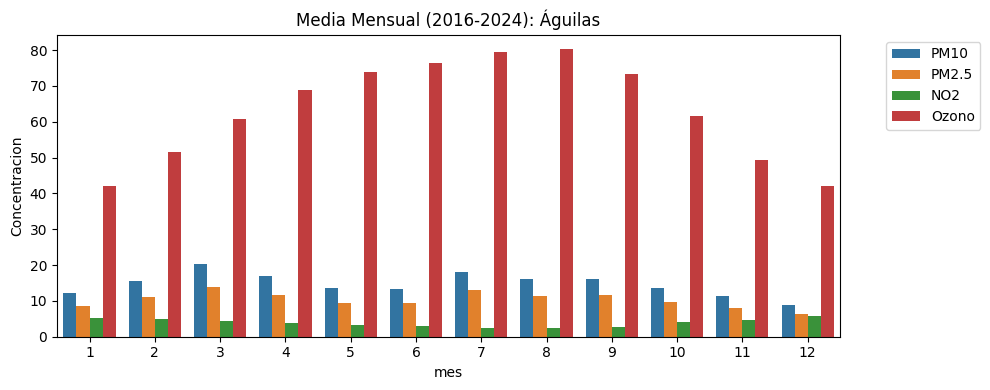

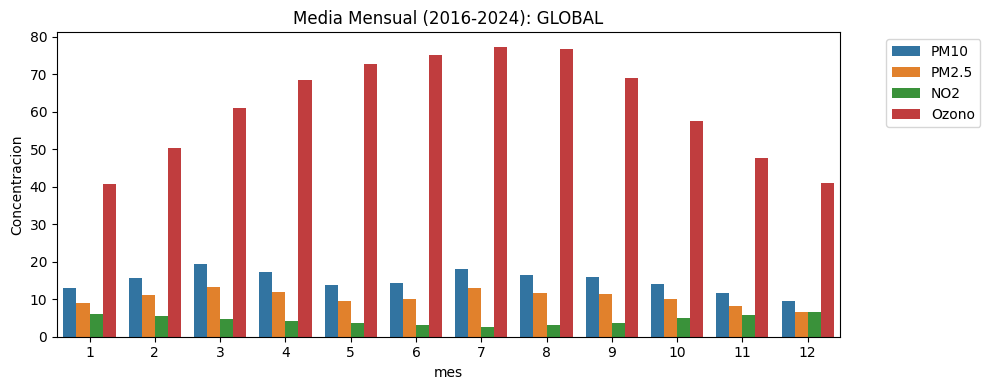

In [27]:
import pandas as pd
import numpy as np
import os, joblib, seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# --- 1. CONFIGURACIÓN Y CARGA ---
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"
RUTA_OUTPUT = os.path.join(PATH_BASE, "Modelos_IA_Listos")

df = pd.read_parquet(f"{PATH_BASE}Murcia_Dataset_Completo_Global_3H.parquet")
df['time'] = pd.to_datetime(df['time'])
df['anio'] = df['time'].dt.year
df['mes'] = df['time'].dt.month
features = ['PM10', 'PM2.5', 'NO2', 'Ozono', 'CO', 'SO2', 'Temp', 'Hum',
            'Viento_Vel', 'Viento_Dir', 'Presion', 'Nubes', 'UV_Real',
            'UV_Cielo_Despejado', 'Lluvia', 'Radiacion']

# --- 2. FORMULARIO DE CHECKBOXES (Colab Nativo) ---
#@markdown ### 📊 1.4: Selección de Variables para Análisis (2016-2024)
PM10 = True #@param {type:"boolean"}
PM2_5 = True #@param {type:"boolean"}
NO2 = True #@param {type:"boolean"}
Ozono = True #@param {type:"boolean"}
CO = False #@param {type:"boolean"}
SO2 = False #@param {type:"boolean"}
Temp = False #@param {type:"boolean"}
Hum = False #@param {type:"boolean"}
Viento_Vel = False #@param {type:"boolean"}
Viento_Dir = False #@param {type:"boolean"}
Presion = False #@param {type:"boolean"}
Nubes = False #@param {type:"boolean"}
UV_Real = False #@param {type:"boolean"}
UV_Cielo_Despejado = False #@param {type:"boolean"}
Lluvia = False #@param {type:"boolean"}
Radiacion = False #@param {type:"boolean"}

seleccion = {
    'PM10': PM10, 'PM2.5': PM2_5, 'NO2': NO2, 'Ozono': Ozono,
    'CO': CO, 'SO2': SO2, 'Temp': Temp, 'Hum': Hum,
    'Viento_Vel': Viento_Vel, 'Viento_Dir': Viento_Dir, 'Presion': Presion,
    'Nubes': Nubes, 'UV_Real': UV_Real,
    'UV_Cielo_Despejado': UV_Cielo_Despejado, 'Lluvia': Lluvia, 'Radiacion': Radiacion
}
vars_plot = [k for k, v in seleccion.items() if v]

# --- 3. GENERADOR DE GRÁFICAS (Media Mensual 2016-2024) ---
df_periodo = df[(df['anio'] >= 2016) & (df['anio'] <= 2024)].copy()
estaciones = list(df_periodo['Estacion'].unique()) + ['GLOBAL']

print(f"📈 Generando 16 gráficas para: {vars_plot}")

for est in estaciones:
    subset = df_periodo if est == 'GLOBAL' else df_periodo[df_periodo['Estacion'] == est]

    # Media mensual agregada 2016-2024
    resumen = subset.groupby('mes')[vars_plot].mean().reset_index()
    resumen_melt = resumen.melt(id_vars='mes', var_name='Variable', value_name='Concentracion')

    plt.figure(figsize=(10, 4))
    sns.barplot(data=resumen_melt, x='mes', y='Concentracion', hue='Variable')
    plt.title(f"Media Mensual (2016-2024): {est}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



In [21]:
import pandas as pd
import numpy as np
import os, joblib
import tensorflow as tf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1. Configuración y Carga
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"
RUTA_OUTPUT = os.path.join(PATH_BASE, "Modelos_IA_Listos")
os.makedirs(RUTA_OUTPUT, exist_ok=True)

df = pd.read_parquet(f"{PATH_BASE}Murcia_Dataset_Completo_Global_3H.parquet")
df['time'] = pd.to_datetime(df['time'])
df['anio'] = df['time'].dt.year
df['mes'] = df['time'].dt.month
features = ['PM10', 'PM2.5', 'NO2', 'Ozono', 'CO', 'SO2', 'Temp', 'Hum',
            'Viento_Vel', 'Viento_Dir', 'Presion', 'Nubes', 'UV_Real',
            'UV_Cielo_Despejado', 'Lluvia', 'Radiacion']
estaciones = list(df['Estacion'].unique()) + ['GLOBAL']

unidades = {'PM10': 'µg/m³', 'PM2.5': 'µg/m³', 'NO2': 'µg/m³', 'Ozono': 'µg/m³', 'CO': 'mg/m³', 'SO2': 'µg/m³', 'Temp': '°C', 'Hum': '%', 'Viento_Vel': 'm/s', 'Viento_Dir': '°', 'Presion': 'hPa', 'Nubes': 'oktas', 'UV_Real': 'W/m²', 'UV_Cielo_Despejado': 'W/m²', 'Lluvia': 'mm', 'Radiacion': 'W/m²'}

# 2. Cálculo de tendencias OLS
print("🚀 Calculando tendencias OLS...")
tasas_anuales, tasas_mensuales = {}, {}
for est in estaciones:
    sub = df if est == 'GLOBAL' else df[df['Estacion'] == est]
    m_anio = sub.groupby('anio')['NO2'].mean().reset_index()
    slope, _, _, _, _ = stats.linregress(m_anio['anio'], m_anio['NO2'])
    tasas_anuales[est] = slope
    for mes in range(1, 13):
        m = sub[sub['mes'] == mes].groupby('anio')['NO2'].mean().reset_index()
        tasas_mensuales[(est, mes)] = stats.linregress(m['anio'], m['NO2'])[0] if len(m) > 2 else 0

# 3. Entrenamiento: Arquitectura LSTM Completa (Sin optimizar para máxima precisión)
print("🚀 Iniciando entrenamiento exhaustivo...")
def create_sequences(data, seq=8):
    x, y = [], []
    for i in range(len(data)-seq): x.append(data[i:i+seq]); y.append(data[i+seq, 0])
    return np.array(x), np.array(y)

for est in estaciones:
    model_path = os.path.join(RUTA_OUTPUT, f"modelo_{est.replace(' ', '_')}.keras")
    if not os.path.exists(model_path):
        subset = (df if est == 'GLOBAL' else df[df['Estacion'] == est])[features].fillna(0).values
        scaler = StandardScaler().fit(subset)
        joblib.dump(scaler, os.path.join(RUTA_OUTPUT, f"scaler_{est.replace(' ', '_')}.save"))

        X, y = create_sequences(scaler.transform(subset))

        tf.keras.backend.clear_session()
        # Arquitectura LSTM profunda (Completa)
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(8, 16)),
            tf.keras.layers.LSTM(64, return_sequences=True),
            tf.keras.layers.Dropout(0.2), # Dropout para combatir overfitting
            tf.keras.layers.LSTM(32),
            tf.keras.layers.Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        model.fit(X, y, epochs=15, batch_size=32, verbose=1) # 15 épocas
        model.save(model_path)
        print(f"✅ Entrenado exhaustivamente: {est}")

# 4. Motor de Predicción (Interfaz Compatible con GitHub)
#@markdown ### 🔮 Motor de Predicción
localidad = 'Alcantarilla' #@param ['Alcantarilla', 'Murcia Capital', 'Cartagena', 'Lorca', 'Molina de Segura', 'Torre-Pacheco', 'Águilas', 'Cieza', 'Yecla', 'San Javier', 'Mazarrón', 'Totana', 'Jumilla', 'Caravaca de la Cruz', 'Archena', 'GLOBAL']
contaminante = 'Ozono' #@param ['PM10', 'PM2.5', 'NO2', 'Ozono', 'CO', 'SO2', 'Temp', 'Hum', 'Viento_Vel', 'Viento_Dir', 'Presion', 'Nubes', 'UV_Real', 'UV_Cielo_Despejado', 'Lluvia', 'Radiacion']
anio_pred = 2026 #@param [2026, 2027]
mes_pred = 3 #@param {type:"slider", min:1, max:12, step:1}

def predecir():
    est = localidad.replace(' ', '_')
    model = tf.keras.models.load_model(os.path.join(RUTA_OUTPUT, f"modelo_{est}.keras"))
    scaler = joblib.load(os.path.join(RUTA_OUTPUT, f"scaler_{est}.save"))

    subset = df if localidad == 'GLOBAL' else df[df['Estacion'] == localidad]
    m_val = subset[subset['mes'] == mes_pred][features].mean().values.reshape(1, -1)

    # Crear secuencia (8, 16)
    m_seq = np.repeat(m_val, 8, axis=0).reshape(1, 8, 16)
    scale_in = scaler.transform(m_seq.reshape(8, 16)).reshape(1, 8, 16)
    pred_base = model.predict(scale_in, verbose=0)[0, 0]

    # Desescalar
    dummy = np.zeros((1, 16))
    dummy[0, features.index(contaminante)] = pred_base
    pred_final = scaler.inverse_transform(dummy)[0, features.index(contaminante)]

    # Ajuste final OLS
    final = max(0, pred_final + ((tasas_anuales[localidad] + tasas_mensuales[(localidad, mes_pred)]) * (anio_pred - 2024)))
    print(f"--- RESULTADO IA ---")
    print(f"🔮 Predicción {contaminante} ({mes_pred}/{anio_pred}) en {localidad}: {final:.2f} {unidades.get(contaminante, '')}")

predecir()

🚀 Calculando tendencias OLS...
🚀 Iniciando entrenamiento exhaustivo...
--- RESULTADO IA ---
🔮 Predicción Ozono (3/2026) en Alcantarilla: 60.12 µg/m³


In [22]:
import pandas as pd
import numpy as np
import os, joblib
import tensorflow as tf
from scipy import stats
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1. Configuración de Entorno
if not os.path.exists('/content/drive'): drive.mount('/content/drive')
PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"
RUTA_OUTPUT = os.path.join(PATH_BASE, "Modelos_IA_Listos")
os.makedirs(RUTA_OUTPUT, exist_ok=True)

# 2. Carga y Preparación
df = pd.read_parquet(f"{PATH_BASE}Murcia_Dataset_Completo_Global_3H.parquet")
df['time'] = pd.to_datetime(df['time'])
df['anio'] = df['time'].dt.year
df['mes'] = df['time'].dt.month
features = ['PM10', 'PM2.5', 'NO2', 'Ozono', 'CO', 'SO2', 'Temp', 'Hum',
            'Viento_Vel', 'Viento_Dir', 'Presion', 'Nubes', 'UV_Real',
            'UV_Cielo_Despejado', 'Lluvia', 'Radiacion']
estaciones = list(df['Estacion'].unique()) + ['GLOBAL']

# Diccionario de unidades para el rigor científico
unidades = {
    'PM10': 'µg/m³', 'PM2.5': 'µg/m³', 'NO2': 'µg/m³', 'Ozono': 'µg/m³',
    'CO': 'mg/m³', 'SO2': 'µg/m³', 'Temp': '°C', 'Hum': '%',
    'Viento_Vel': 'm/s', 'Viento_Dir': '°', 'Presion': 'hPa',
    'Nubes': 'oktas', 'UV_Real': 'W/m²', 'UV_Cielo_Despejado': 'W/m²',
    'Lluvia': 'mm', 'Radiacion': 'W/m²'
}

# 3. Tendencias OLS (Corrección por regresión lineal)
print("🚀 Calculando tendencias OLS...")
tasas_anuales, tasas_mensuales = {}, {}
for est in estaciones:
    sub = df if est == 'GLOBAL' else df[df['Estacion'] == est]
    m_anio = sub.groupby('anio')['NO2'].mean().reset_index()
    slope, _, _, _, _ = stats.linregress(m_anio['anio'], m_anio['NO2'])
    tasas_anuales[est] = slope
    for mes in range(1, 13):
        m = sub[sub['mes'] == mes].groupby('anio')['NO2'].mean().reset_index()
        tasas_mensuales[(est, mes)] = stats.linregress(m['anio'], m['NO2'])[0] if len(m) > 2 else 0

# 4. Entrenamiento Masivo LSTM
print("🚀 Iniciando entrenamiento...")
for est in estaciones:
    model_path = os.path.join(RUTA_OUTPUT, f"modelo_{est.replace(' ', '_')}.keras")
    if not os.path.exists(model_path):
        subset = (df if est == 'GLOBAL' else df[df['Estacion'] == est])[features].fillna(0).values
        scaler = StandardScaler().fit(subset)
        joblib.dump(scaler, os.path.join(RUTA_OUTPUT, f"scaler_{est.replace(' ', '_')}.save"))

        X, y = [], []
        d_s = scaler.transform(subset)
        for i in range(len(d_s)-8): X.append(d_s[i:i+8]); y.append(d_s[i+8, 0])

        tf.keras.backend.clear_session()
        model = tf.keras.Sequential([tf.keras.layers.Input(shape=(8, 16)), tf.keras.layers.LSTM(32), tf.keras.layers.Dense(1)])
        model.compile(optimizer='adam', loss='mse')
        model.fit(np.array(X), np.array(y), epochs=5, batch_size=128, verbose=0)
        model.save(model_path)
        print(f"✅ Entrenado: {est}")

# 5. Motor de Predicción (Interfaz Compatible con GitHub/PDF)
#@markdown ### 🔮 Motor de Predicción
localidad = 'Alcantarilla' #@param ['Alcantarilla', 'Murcia Capital', 'Cartagena', 'Lorca', 'Molina de Segura', 'Torre-Pacheco', 'Águilas', 'Cieza', 'Yecla', 'San Javier', 'Mazarrón', 'Totana', 'Jumilla', 'Caravaca de la Cruz', 'Archena', 'GLOBAL']
contaminante = 'Ozono' #@param ['PM10', 'PM2.5', 'NO2', 'Ozono', 'CO', 'SO2', 'Temp', 'Hum', 'Viento_Vel', 'Viento_Dir', 'Presion', 'Nubes', 'UV_Real', 'UV_Cielo_Despejado', 'Lluvia', 'Radiacion']
anio_pred = 2026 #@param [2026, 2027]
mes_pred = 3 #@param {type:"slider", min:1, max:12, step:1}

def predecir():
    tf.keras.backend.clear_session()
    est = localidad.replace(' ', '_')
    model = tf.keras.models.load_model(os.path.join(RUTA_OUTPUT, f"modelo_{est}.keras"))
    scaler = joblib.load(os.path.join(RUTA_OUTPUT, f"scaler_{est}.save"))

    subset = df if localidad == 'GLOBAL' else df[df['Estacion'] == localidad]
    m_val = subset[subset['mes'] == mes_pred][features].mean().values.reshape(1, -1)

    # Crear secuencia (8, 16)
    m_seq = np.repeat(m_val, 8, axis=0).reshape(1, 8, 16)
    scale_in = scaler.transform(m_seq.reshape(8, 16)).reshape(1, 8, 16)
    pred_base = model.predict(scale_in, verbose=0)[0, 0]

    # Desescalar
    dummy = np.zeros((1, 16))
    dummy[0, features.index(contaminante)] = pred_base
    pred_final = scaler.inverse_transform(dummy)[0, features.index(contaminante)]

    # Ajuste final OLS
    final = max(0, pred_final + ((tasas_anuales[localidad] + tasas_mensuales[(localidad, mes_pred)]) * (anio_pred - 2024)))

    print(f"--- RESULTADO IA  ---")
    print(f"🔮 Predicción {contaminante} ({mes_pred}/{anio_pred}) en {localidad}: {final:.2f} {unidades.get(contaminante, '')}")

predecir()

🚀 Calculando tendencias OLS...
🚀 Iniciando entrenamiento...
--- RESULTADO IA  ---
🔮 Predicción Ozono (3/2026) en Alcantarilla: 60.12 µg/m³
